# Generate a random SI Field from alm and Cl

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.special import eval_legendre
from astropy.io import fits
import os
import time

In [2]:
# Set seed for reproducibility seed =42
np.random.seed(42)


In [3]:
# seed = 42

# Define maximum l value
l_max = 500

# Number of alm coefficients
num_alm = hp.Alm.getsize(l_max)

print(f"Number of alm coefficients for l_max={l_max}: {num_alm}")

# Generate random real and imaginary parts
real_part = np.random.normal(size=num_alm)
imag_part = np.random.normal(size=num_alm)

# Combine into complex values
alm = real_part + 1j * imag_part

# Print some values
print("Randomly generated a_lm values:")
# for i in range(num_alm):
#     l, m = hp.Alm.getlm(l_max, i)
#     print(f"a_{l}_{m} = {alm[i]:.5f}")

print(alm)

Number of alm coefficients for l_max=500: 125751
Randomly generated a_lm values:
[ 0.49671415+1.28493468j -0.1382643 +0.05247004j  0.64768854-1.40037063j
 ...  0.99679731-1.24358785j -0.88713376-1.22244501j
 -0.30071917-1.23198325j]


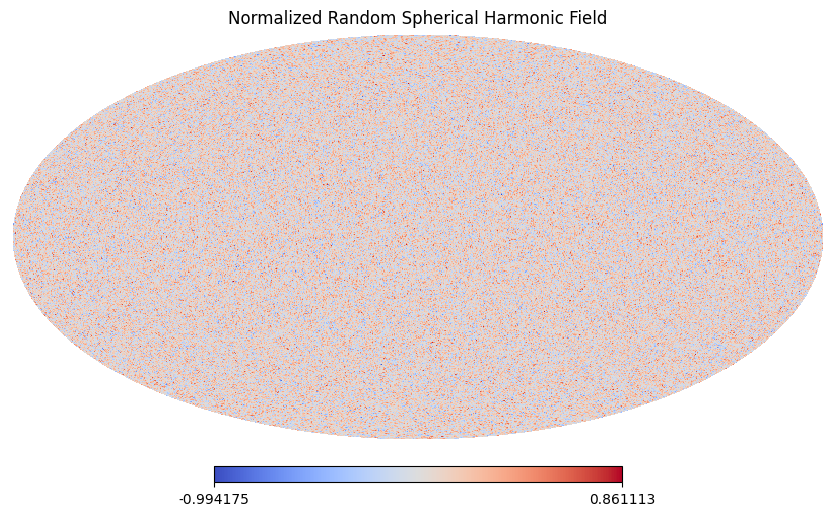

In [19]:
nside = 256 # Set an appropriate NSIDE
map_alm = hp.alm2map(alm, nside, lmax=l_max)

# Plot the map
# hp.mollview(map_alm, title="Random Spherical Harmonic Field", cmap="coolwarm")
# # Normalize the map (to make sure all values lie between -1 and 1)
map_alm -= np.mean(map_alm)
map_alm /= np.max(np.abs(map_alm))

# Plot the normalized map
hp.mollview(map_alm, title="Normalized Random Spherical Harmonic Field", cmap="coolwarm")

In [20]:
# Set seed for reproducibility seed = 36
np.random.seed(36)
n1 = np.random.randint(hp.nside2npix(nside))
npix =hp.nside2npix(nside)
print(n1, npix)

222110 786432


In [21]:
# Define a function to compute the angular separation between two pixels
def angular_separation(n1, n2, nside):
    # Get (theta, phi) for n1 and n2
    # theta_n1, phi_n1 = hp.pix2ang(nside, n1)
    # theta_n2, phi_n2 = hp.pix2ang(nside, n2)
    
    # Calculate the angular separation using HEALPix's built-in function
    return hp.rotator.angdist(hp.pix2vec(nside, n1), hp.pix2vec(nside, n2))

# Calculate C($\theta$) by looping over n1 and n2

In [22]:
def compute_C_theta(theta_values, map_data, nside, tolerance=0.0001):
    """
    Compute C(θ) by integrating over all pixel pairs (n, n') with angular separation θ.

    Parameters:
        theta_values (array): Array of theta values to compute C(θ).
        map_data (array): HEALPix map containing DeltaT values.
        nside (int): HEALPix resolution parameter.
        tolerance (float): Tolerance for matching angular separation.

    Returns:
        array: C(θ) values for each theta in theta_values.
    """
    npix = hp.nside2npix(nside)
    C_theta = np.zeros_like(theta_values)

    for i, theta in enumerate(theta_values):
        print(i, theta)
        sum_C = 0
        count = 0
        
        for n in range(npix):
            # vec_n = hp.pix2vec(nside, n)
            # if n/100 == 0:
            print(n)
            for n_prime in range(npix):
                #  Compute angular separation
                theta_np = psi_n2 = angular_separation(n, n_prime, nside)

                # vec_n_prime = hp.pix2vec(nside, n_prime)
                # cos_theta_np = np.dot(vec_n, vec_n_prime)
                # theta_np = np.arccos(np.clip(cos_theta_np, -1, 1))

                # Check if the separation is within the tolerance range
                if np.abs(theta_np - theta) < tolerance:
                    sum_C += map_data[n] * map_data[n_prime]
                    # count += 1
        
        # Normalize the sum
        # if count > 0:
        C_theta[i] = sum_C / (4*np.pi)

    return C_theta

# theta_values = np.linspace(0, np.pi, 20)  # Define θ values from 0 to π
# theta_values = np.linspace(0.1, np.pi, 3) 
# print(theta_values)
# C_theta_result = compute_C_theta(theta_values, map_alm, nside)

# # Plot the result
# plt.figure(figsize=(10, 6))
# plt.plot(theta_values, C_theta_result, label="C(θ)")
# plt.xlabel("θ (radians)")
# plt.ylabel("C(θ)")
# plt.legend()
# plt.show()


# Calculate $C_{n_1}(\psi)$ by looping over n2 with const n1

In [23]:
# Function to compute C_n1(psi) by integrating over pixels whose angular separation is approximately psi
def compute_Cn1_psi(n1, map_data, psi_values, nside, tolerance=0.0001):
    C_n1_psi = np.zeros(len(psi_values))
    
    # For each value of psi, integrate over all pixels n2
    for i, psi in enumerate(psi_values):
        print(i, psi)
        C_n1_psi_val = 0
        
        # Loop over all pixels n2
        for n2 in range(hp.nside2npix(nside)):
            # Calculate the angular separation between n1 and n2
            psi_n2 = angular_separation(n1, n2, nside)
            
            # Check if the angular separation is within the tolerance range of psi
            if np.abs(psi_n2 - psi) < tolerance:
                # Add the contribution of Delta T(n1) * Delta T(n2)
                C_n1_psi_val += map_data[n1] * map_data[n2]
        
        # Normalize by the number of pixels and the solid angle factor (dOmega)
        C_n1_psi[i] = C_n1_psi_val / (4 * np.pi)
    
    return C_n1_psi

# Set up the psi values to calculate C_n1(psi)
# psi_values = np.linspace(0, np.pi, 10)  # Array of psi from 0 to pi

# # Compute C_n1(psi)
# C_n1_psi_result = compute_Cn1_psi(n1, map_alm, psi_values, nside)

# # 6. Plot the result
# plt.figure(figsize=(10, 6))
# plt.plot(psi_values, C_n1_psi_result)
# plt.title(f"C_n1(psi) for n1 = {n1}")
# plt.xlabel(r"$\psi$ (rad)")
# plt.ylabel(r"$C_{n1}(\psi)$")
# plt.grid(True)
# plt.show()

# Calculate $C_{001}(\psi)$ by averaging over $\varphi$ with const. n1 (after Rotation n1-> 001)

In [24]:
rotated_map =  map_alm #no rotation applied for now

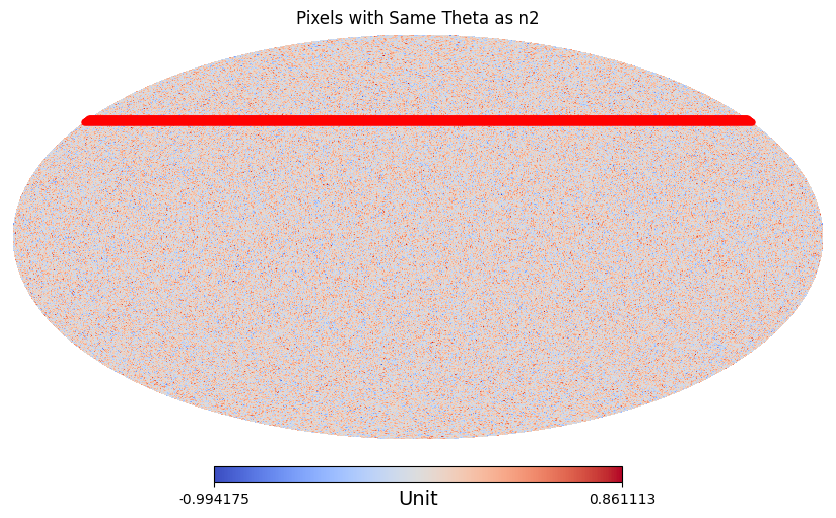

In [25]:
# Choose a random pixel n2
np.random.seed(42)
n2 = np.random.randint(hp.nside2npix(nside))

# Get theta, phi of n2 (in radians)
theta_n2, phi_n2 = hp.pix2ang(nside, n2)

Delta = np.pi/100  # Example value for tolerance in radians

# Calculate the angular separation for all pixels (theta values)
theta_all, phi_all = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))

# Find all pixels where theta is within the range [theta_n2 - Delta/2, theta_n2 + Delta/2]
same_theta_pixels = np.where((theta_all >= (theta_n2 - Delta/2)) & (theta_all <= (theta_n2 + Delta/2)))[0]


# Plot the map using mollview
hp.mollview(rotated_map, title="Pixels with Same Theta as n2", unit="Unit", cbar=True, cmap="coolwarm" )

# Plot all pixels with the same theta value as n2
hp.projscatter(theta_all[same_theta_pixels], phi_all[same_theta_pixels], marker='o', color='red', s=10)

# Show the plot
plt.show()

### Calculate C_001 function


In [26]:
def get_C001(rmap, psi_values, Delta_psi):
    nside = hp.get_nside(rmap)
    C_001 = np.zeros_like(psi_values)
    theta_all, phi_all = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
    
    # Calculate C_001(psi) = Integral dvarphi DeltaT(0,0) * DeltaT(psi, varphi)
    for i, psi in enumerate(psi_values):
        # Create an array to store the temperature differences
        temp_prod = []

        # t0 =time.perf_counter()
        
        # t1 = time.perf_counter()
        same_theta_pixels = np.where((theta_all >= (psi - Delta_psi/2)) & (theta_all <= (psi + Delta_psi/2)))[0]
        # t2 = time.perf_counter()
        # p = rmap[hp.ang2pix(nside, theta_all[same_theta_pixels], phi_all[same_theta_pixels])]*rmap[hp.ang2pix(nside, 0, 0)]
        # t2b = time.perf_counter()
        temp_prod.append(rmap[hp.ang2pix(nside, theta_all[same_theta_pixels], phi_all[same_theta_pixels])]*rmap[hp.ang2pix(nside, 0, 0)])
        # t3 = time.perf_counter()

        # if len(temp_prod) == 0:
            # print(i,psi,"This has NAN ---------------------")

        if len(temp_prod) > 0:
            # print(same_theta_pixels, theta_all[same_theta_pixels], phi_all[same_theta_pixels], np.mean(temp_prod))
            C_001[i] = np.mean(temp_prod)
        if i>0 and i % 200 == 0:
            print(f"{i}, psi: {psi}, C_001(psi):{C_001[i]}")
        # t4 = time.perf_counter()


        # print(f"Timing for psi {i}:")
        # print(f"  theta_all, phi_all creation: {t1 - t0:.4f} s")
        # print(f"  same_theta pixels array: {t2 - t0:.4f} s")
        # print(f"  product : {t2b - t2:.4f} s")
        # print(f"  Appending values: {t3 - t2b:.4f} s")
        # print(f"  Averaging all values: {t4 - t3:.4f} s")
        # print("=" * 40)


    return C_001


In [27]:
n_psi = 1000
psi_values = np.linspace(0.004, np.pi, n_psi)
Delta_psi = 0.01 #np.pi / n_psi

print(f"Delta_psi: {Delta_psi}\n")

C_001 = get_C001(rotated_map, psi_values, Delta_psi)

# print(C_001)

Delta_psi: 0.01

200, psi: 0.6321466773953539, C_001(psi):-1.1885549192971993e-06
400, psi: 1.2602933547907078, C_001(psi):2.757155598992439e-06
600, psi: 1.888440032186062, C_001(psi):-8.198414829472771e-06
800, psi: 2.5165867095814156, C_001(psi):-9.63141854172455e-06


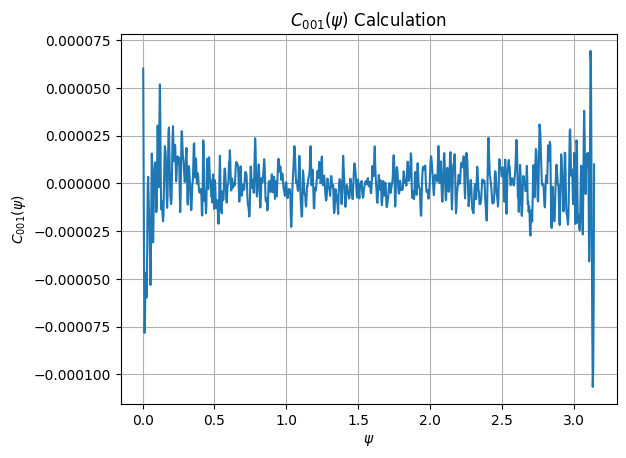

In [28]:
# Plot the result
plt.plot(psi_values, C_001)
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"$C_{001}(\psi)$ Calculation")
plt.grid(True)
plt.show()

In [29]:
theta_n1, phi_n1 = hp.pix2ang(nside, n1)
theta_n2, phi_n2 = hp.pix2ang(nside, n1+1)
print(f"theta_n1: {theta_n1:.2f}, phi_n1: {phi_n1:.2f}")
print(f"theta_n2: {theta_n2:.2f}, phi_n2: {phi_n2:.2f}")
print(f"Delta theta: {np.abs(theta_n1 - theta_n2):.2f}, Delta phi: {np.abs(phi_n1 - phi_n2):.2f}")

theta_n1: 1.12, phi_n1: 2.54
theta_n2: 1.12, phi_n2: 2.55
Delta theta: 0.00, Delta phi: 0.01


## Take C_l - Gaussian

### Calculate Theoretical $ C(\psi) $ from $C_{\ell}$

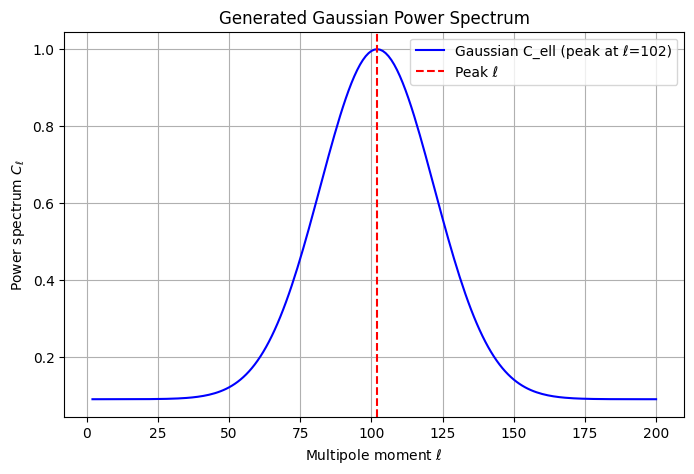

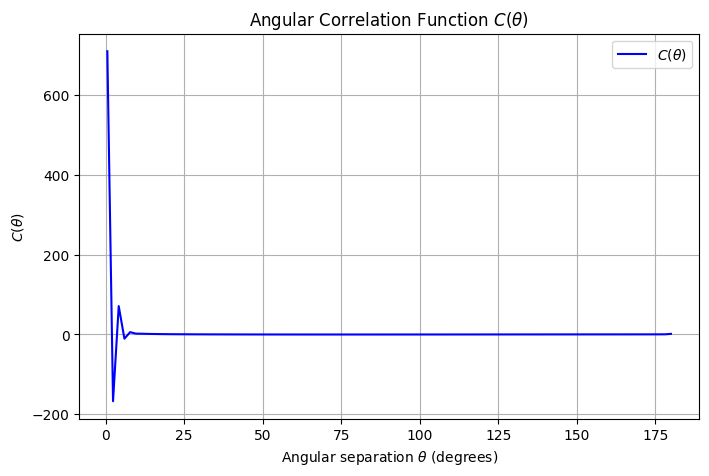

In [30]:
# Set a random seed for reproducibility
np.random.seed(42)

# Define the range of multipoles
l_max = 200  # Maximum multipole value
ell = np.arange(2, l_max + 1)  # Avoid ell=0,1 (monopole and dipole)

# Choose a random peak multipole (Gaussian center)
l_peak = np.random.randint(0, l_max)  # Random center between l=50 and l=150
sigma = 20  # Width of the Gaussian

# Generate a Gaussian power spectrum Cl
cl = np.exp(-0.5 * ((ell - l_peak) / sigma) ** 2) + 0.1  # Gaussian around l_peak
cl /= np.max(cl)  # Normalize to 1 for visualization

# Extend Cl to ell=0,1
# cl_full = np.zeros(l_max + 1)
# cl_full[2:] = cl  # Fill from l=2 onward

# ---- Compute C(theta) ----
psi = np.linspace(0.01, np.pi, 100)  # Angular separation from 0 to π
c_theta = np.zeros_like(psi)

for i, t in enumerate(psi):
    # print(i, t)
    legendre_vals = np.array(eval_legendre(ell, np.cos(t)) ) # P_l(cosθ)
    # print(legendre_vals)
    c_theta[i] = np.sum((2 * ell + 1) / (4 * np.pi) * cl * legendre_vals)  # Sum over ell


# Simulate a HEALPix map using the generated Cl
gaussian_map = hp.synfast(cl, nside)  # Convert to pixel space

# ---- Plot C_ell ----
plt.figure(figsize=(8, 5))
plt.plot(ell, cl, label=f'Gaussian C_ell (peak at ℓ={l_peak})', color='b')
plt.axvline(l_peak, color='r', linestyle='--', label='Peak ℓ')
plt.xlabel(r'Multipole moment $\ell$')
plt.ylabel(r'Power spectrum $C_\ell$')
plt.title('Generated Gaussian Power Spectrum')
plt.legend()
plt.grid()
plt.show()

# ---- Plot C(theta) ----
plt.figure(figsize=(8, 5))
plt.plot(np.degrees(psi), c_theta, color='b', label=r'$C(\theta)$')
plt.xlabel(r'Angular separation $\theta$ (degrees)')
plt.ylabel(r'$C(\theta)$')
plt.title('Angular Correlation Function $C(\\theta)$')
plt.legend()
plt.grid()
plt.show()


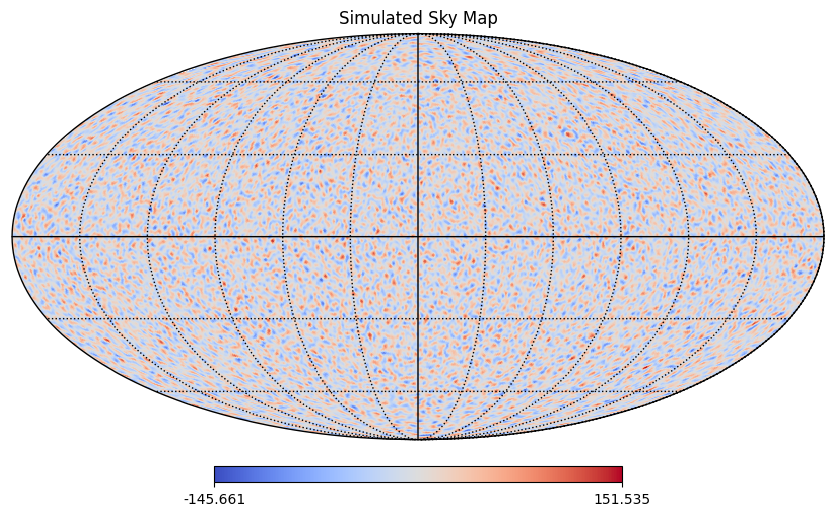

In [31]:
# ---- Plot the Healpy Map ----
hp.mollview(gaussian_map, title='Simulated Sky Map', cmap='coolwarm')
hp.graticule()
plt.show()

200, psi: 0.6321466773953539, C_001(psi):-39.90120420440856
400, psi: 1.2602933547907078, C_001(psi):2.435405244516966
600, psi: 1.888440032186062, C_001(psi):-6.6297724614948725
800, psi: 2.5165867095814156, C_001(psi):31.52321544954879


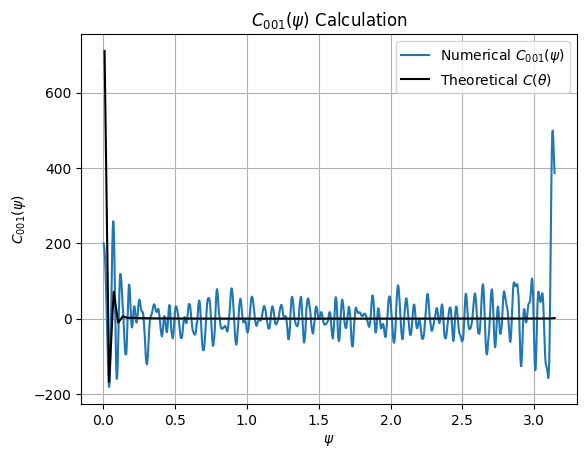

In [32]:
# takes about 8 sec for thousand psi values
C_001 = get_C001(gaussian_map, psi_values, Delta_psi)

# Plot the result
plt.plot(psi_values, C_001, label = r'Numerical $C_{001}(\psi)$')
plt.plot(psi, c_theta, color='black', label=r'Theoretical $C(\theta)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"$C_{001}(\psi)$ Calculation")
plt.grid(True)
plt.legend()
plt.show()

Rotated Sky Map 0: alpha=0, beta=0, gamma=0.0
Rotated Sky Map 1: alpha=0, beta=0, gamma=0.06346651825433926
Rotated Sky Map 2: alpha=0, beta=0, gamma=0.12693303650867852
Rotated Sky Map 3: alpha=0, beta=0, gamma=0.1903995547630178
Rotated Sky Map 4: alpha=0, beta=0, gamma=0.25386607301735703
Rotated Sky Map 5: alpha=0, beta=0, gamma=0.3173325912716963
Rotated Sky Map 6: alpha=0, beta=0, gamma=0.3807991095260356
Rotated Sky Map 7: alpha=0, beta=0, gamma=0.4442656277803748
Rotated Sky Map 8: alpha=0, beta=0, gamma=0.5077321460347141
Rotated Sky Map 9: alpha=0, beta=0, gamma=0.5711986642890533
Rotated Sky Map 10: alpha=0, beta=0, gamma=0.6346651825433925
Rotated Sky Map 11: alpha=0, beta=0, gamma=0.6981317007977318
Rotated Sky Map 12: alpha=0, beta=0, gamma=0.7615982190520711
Rotated Sky Map 13: alpha=0, beta=0, gamma=0.8250647373064104
Rotated Sky Map 14: alpha=0, beta=0, gamma=0.8885312555607496
Rotated Sky Map 15: alpha=0, beta=0, gamma=0.9519977738150889
Rotated Sky Map 16: alpha=0, b

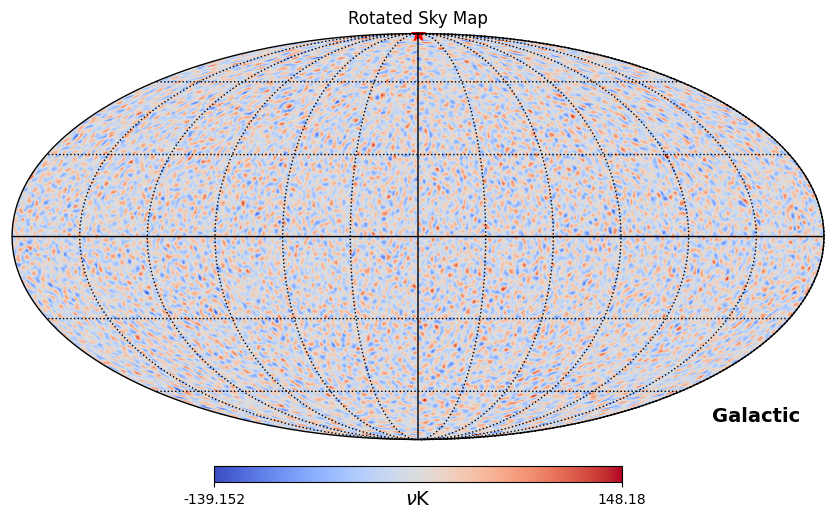

Rotated Sky Map 26: alpha=0, beta=0, gamma=1.6501294746128208
Rotated Sky Map 27: alpha=0, beta=0, gamma=1.71359599286716
Rotated Sky Map 28: alpha=0, beta=0, gamma=1.7770625111214993
Rotated Sky Map 29: alpha=0, beta=0, gamma=1.8405290293758385
Rotated Sky Map 30: alpha=0, beta=0, gamma=1.9039955476301778
Rotated Sky Map 31: alpha=0, beta=0, gamma=1.967462065884517
Rotated Sky Map 32: alpha=0, beta=0, gamma=2.0309285841388562
Rotated Sky Map 33: alpha=0, beta=0, gamma=2.0943951023931957
Rotated Sky Map 34: alpha=0, beta=0, gamma=2.1578616206475347
Rotated Sky Map 35: alpha=0, beta=0, gamma=2.221328138901874
Rotated Sky Map 36: alpha=0, beta=0, gamma=2.284794657156213
Rotated Sky Map 37: alpha=0, beta=0, gamma=2.3482611754105527
Rotated Sky Map 38: alpha=0, beta=0, gamma=2.4117276936648917
Rotated Sky Map 39: alpha=0, beta=0, gamma=2.475194211919231
Rotated Sky Map 40: alpha=0, beta=0, gamma=2.53866073017357
Rotated Sky Map 41: alpha=0, beta=0, gamma=2.6021272484279097
Rotated Sky Map 

In [ ]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi, n_psi)

alpha = 0
beta = 0
gamma = np.linspace(0, 2*np.pi, int(10000/n_psi))
c_gaussian = []

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)

    rotated_planck_map = rotation.rotate_map_pixel(gaussian_map)
    if abs(gam - np.pi/2) < 0.03:
        hp.mollview(
            rotated_planck_map,
            coord=["G"],
            title="Rotated Sky Map",
            unit=r"$\nu$K",
            # norm="hist",
            cmap="coolwarm",
        )
# hp.mollview(rotated_planck_map, title=)
        hp.graticule()
        hp.projscatter(0, 0, marker='*', color='red', s=100)
        plt.show()
    c_gaussian.append(get_C001(rotated_planck_map, psi_values2, Delta_psi))

c_gaussian = np.array(c_gaussian)  # Ensure it's a 2D array (shape: [iterations, psi_values])

# Compute the average over the 10 iterations
c_gauss_avg = np.mean(c_gaussian, axis=0)

c_gauss1 = []
for n in range(10):
    c_gauss1.append(c_gaussian[n*10])
c_gauss_avg1 = np.mean(c_gauss1, axis=0) 


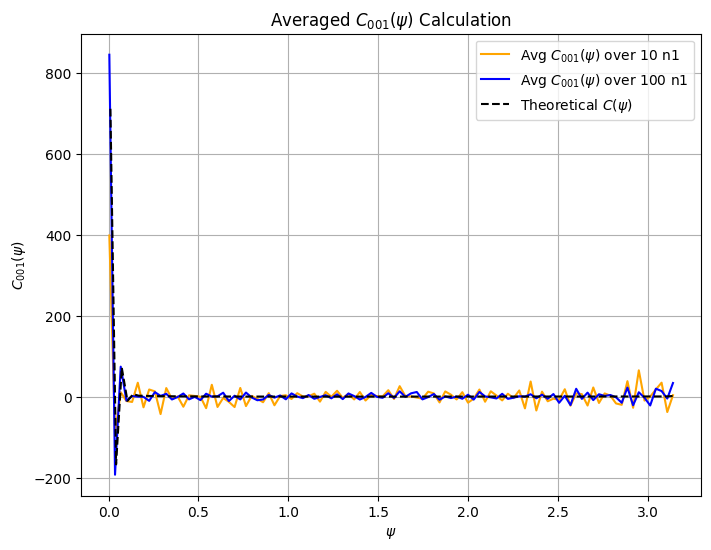

In [ ]:

# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))

plt.plot(psi_values2, c_gauss_avg1, color="orange", label=r"Avg $C_{001}(\psi)$ over 10 n1")
plt.plot(psi_values2, c_gauss_avg, color="blue", label=r"Avg $C_{001}(\psi)$ over 100 n1")

plt.plot(psi, c_theta,"--", color='black', label=r'Theoretical $C(\psi)$')

plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

## Use Planck Map

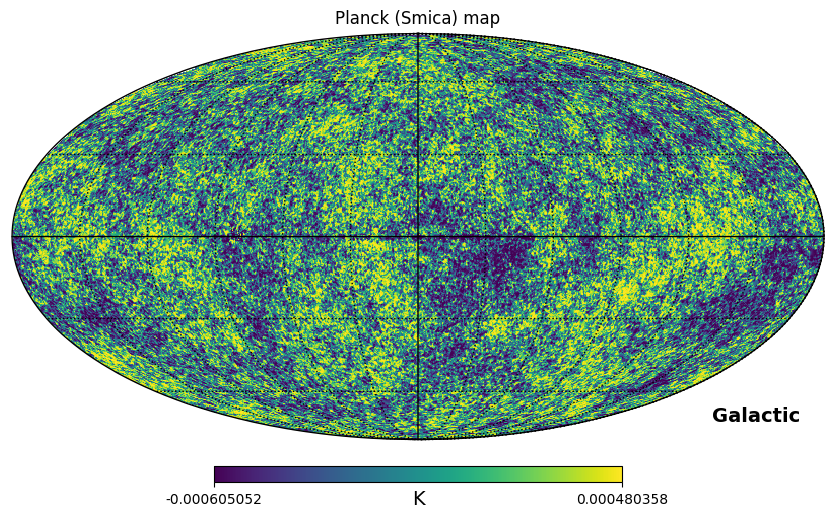

In [35]:
# Path to the FITS file
fits_file_path = f'{os.getcwd()}/Data/CMB-Planck_Smica_nosz_map_2048_R3.fits'
fits_file_path = f'{os.getcwd()}/Data/galactic_output_map_1.fits'

Planck_Smica_map = hp.read_map(fits_file_path, field =0)

hp.mollview(
    Planck_Smica_map,
    coord=["G"],
    title="Planck (Smica) map",
    unit="K",
    norm="hist",
    # cmap = "coolwarm",
)
hp.graticule()

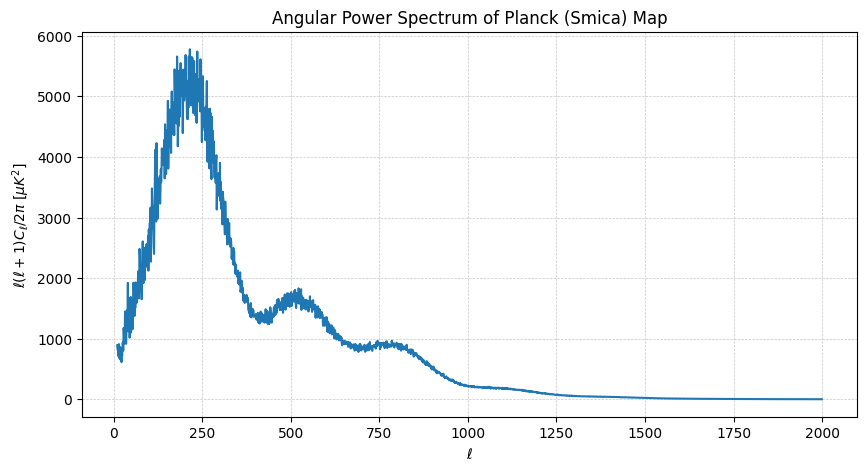

In [36]:
LMAX = 2000
cl_planck = hp.anafast(Planck_Smica_map,  lmax=LMAX)
ell_planck = np.arange(len(cl_planck))

plt.figure(figsize=(10, 5))
plt.plot(ell_planck[10:-1], (ell_planck * (ell_planck + 1) * cl_planck *1e12/(2*np.pi))[10:-1])
# plt.scatter(ell[10:-1], (ell * (ell + 1) * cl *1.9e6/(2*np.pi))[10:-1], s=3 )
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell} / 2\pi$ $[\mu K^2]$")
# plt.xscale("log")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title("Angular Power Spectrum of Planck (Smica) Map")
plt.show()

# hp.write_cl("cl_planck.fits", cl_planck, overwrite=True)

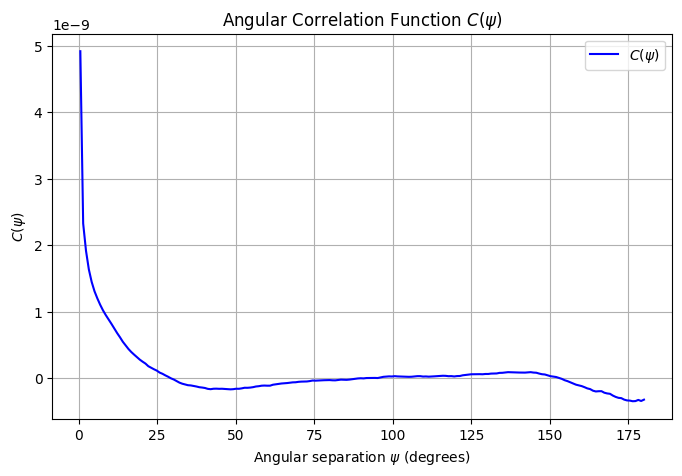

In [37]:
# ---- Compute C(theta) ----
psi = np.linspace(0.01, np.pi, 200)  # Angular separation from 0 to π
c_psi = np.zeros_like(psi)

for i, t in enumerate(psi):
    # print(i, t)
    legendre_vals = eval_legendre(ell_planck, np.cos(t))  # P_l(cosθ)
    # print(legendre_vals[0:2])
    c_psi[i] = np.sum((2 * ell_planck+ 1) / (4 * np.pi) * cl_planck * legendre_vals)  # Sum over ell
    # print(i, t,c_psi[i])

# ---- Plot C(psi) ----
plt.figure(figsize=(8, 5))
plt.plot(np.degrees(psi), c_psi, color='b', label=r'$C(\psi)$')
plt.xlabel(r'Angular separation $\psi$ (degrees)')
plt.ylabel(r'$C(\psi)$')
plt.title('Angular Correlation Function $C(\\psi)$')
plt.legend()
plt.grid()
plt.show()

200, psi: 0.6321466773953539, C_001(psi):1.7010565178665615e-09
400, psi: 1.2602933547907078, C_001(psi):-6.826859910713523e-11
600, psi: 1.888440032186062, C_001(psi):5.275678227611991e-10
800, psi: 2.5165867095814156, C_001(psi):-1.626046519653812e-09


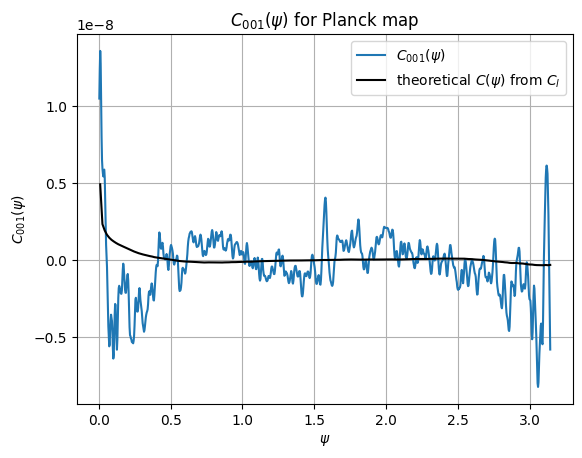

In [38]:

n_psi = 1000
Delta_psi = 0.01 #np.pi / n_psi
psi_values = np.linspace(0.004, np.pi, n_psi)

C_001_planck = get_C001(Planck_Smica_map, psi_values, Delta_psi)
# Plot the result
plt.plot(psi_values, C_001_planck, label = r'$C_{001}(\psi)$')
plt.plot(psi, c_psi, color='black', label=r'theoretical $C(\psi)$ from $C_l$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"$C_{001}(\psi)$ for Planck map")
plt.grid(True)
plt.legend()
plt.show()


In [39]:

n_psi = 100
psi_values2 = np.linspace(0.004, np.pi, n_psi)

n_anchors = 100

alpha = 2*np.pi/3 # arbitrarily chosen
beta = 0
gamma = np.linspace(0, 2*np.pi, int(n_anchors))
c_planck = []

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    # if abs(gam - np.pi/2) < 0.03:
    #     hp.mollview(
    #         rotated_planck_map,
    #         coord=["G"],
    #         title="Rotated Sky Map",
    #         unit="K",
    #         norm="hist",
    #         cmap = "coolwarm",
    #     )

    #     hp.graticule()
    #     hp.projscatter(0, 0, marker='*', color='red', s=100)
    #     plt.show()
    c_planck.append(get_C001(rotated_planck_map, psi_values2, Delta_psi))


Rotated Sky Map 0: alpha=2.0943951023931953, beta=0, gamma=0.0
Rotated Sky Map 1: alpha=2.0943951023931953, beta=0, gamma=0.06346651825433926
Rotated Sky Map 2: alpha=2.0943951023931953, beta=0, gamma=0.12693303650867852
Rotated Sky Map 3: alpha=2.0943951023931953, beta=0, gamma=0.1903995547630178
Rotated Sky Map 4: alpha=2.0943951023931953, beta=0, gamma=0.25386607301735703
Rotated Sky Map 5: alpha=2.0943951023931953, beta=0, gamma=0.3173325912716963
Rotated Sky Map 6: alpha=2.0943951023931953, beta=0, gamma=0.3807991095260356
Rotated Sky Map 7: alpha=2.0943951023931953, beta=0, gamma=0.4442656277803748
Rotated Sky Map 8: alpha=2.0943951023931953, beta=0, gamma=0.5077321460347141
Rotated Sky Map 9: alpha=2.0943951023931953, beta=0, gamma=0.5711986642890533
Rotated Sky Map 10: alpha=2.0943951023931953, beta=0, gamma=0.6346651825433925
Rotated Sky Map 11: alpha=2.0943951023931953, beta=0, gamma=0.6981317007977318
Rotated Sky Map 12: alpha=2.0943951023931953, beta=0, gamma=0.761598219052

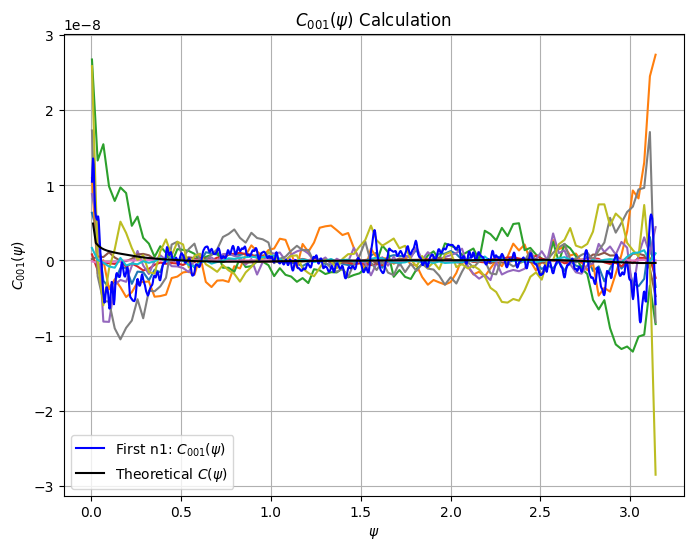

In [40]:
# Plot the result
plt.figure(figsize=(8, 6))
for i, c_pl in enumerate(c_planck):
    if i % 10 == 0:
        plt.plot(psi_values2, c_pl)
    # plt.plot(psi_values2, c_pl)
plt.plot(psi_values, C_001_planck, c='b', label=r'First n1: $C_{001}(\psi)$')
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"$C_{001}(\psi)$ Calculation")
plt.grid(True)
plt.legend()
plt.show()

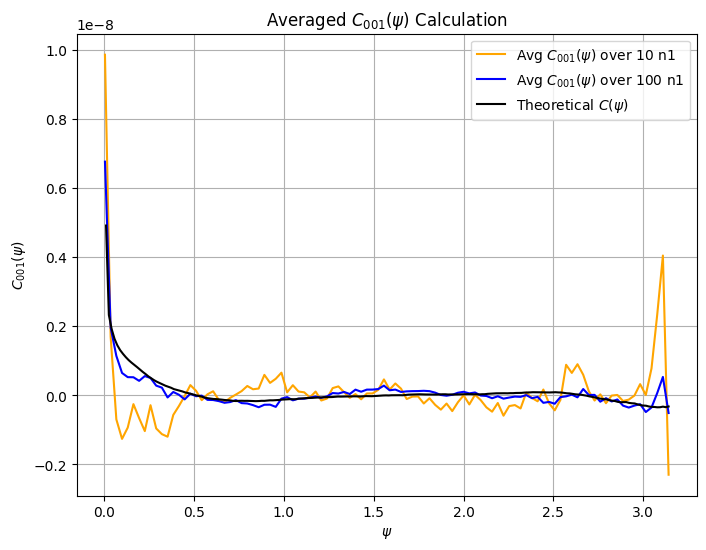

In [41]:
c_planck = np.array(c_planck)  # Ensure it's a 2D array (shape: [iterations, psi_values])

# Compute the average over the 10 iterations
c_planck_avg = np.mean(c_planck, axis=0)

c_planck1 = []
for n in range(10):
    c_planck1.append(c_planck[n*10])
c_planck_avg1 = np.mean(c_planck1, axis=0) 


# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))

plt.plot(psi_values2, c_planck_avg1, color="orange", label=r"Avg $C_{001}(\psi)$ over 10 n1")
plt.plot(psi_values2, c_planck_avg, color="blue", label=r"Avg $C_{001}(\psi)$ over 100 n1")

plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')

plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

### Constant non-zero $\alpha$, $\gamma$ chosen uniformly , n_anchors >= 100



#### $\alpha = 0$

Rotated Sky Map 0: alpha=0, beta=0, gamma=0.0
Rotated Sky Map 50: alpha=0, beta=0, gamma=1.578689775673263
Rotated Sky Map 100: alpha=0, beta=0, gamma=3.157379551346526
Rotated Sky Map 150: alpha=0, beta=0, gamma=4.736069327019789


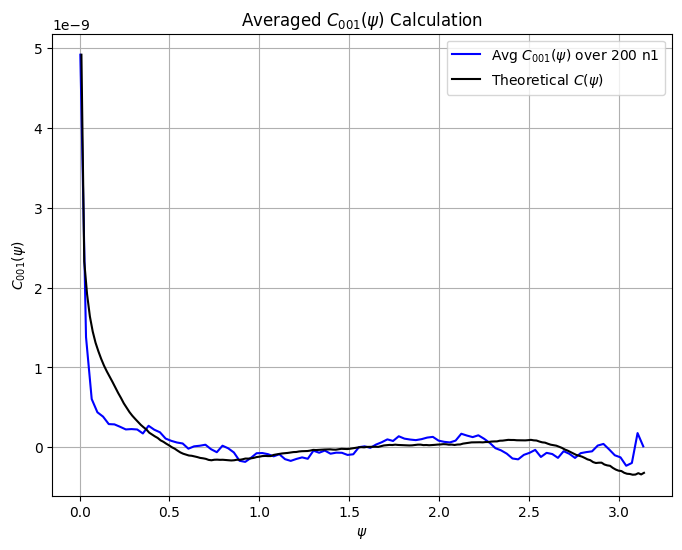

In [42]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)

n_anchors = 200

alpha = 0
beta = 0
gamma = np.linspace(0, 2*np.pi, int(n_anchors))
c_planck1 = np.zeros_like(psi_values2)

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    if i%50 == 0:
        print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    c_planck1 += get_C001(rotated_planck_map, psi_values2, Delta_psi)

# Compute the average over the 10 iterations
c_planck_avg = c_planck1 / len(gamma)

norm1 = c_planck_avg[0]/c_psi[0]
# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))

plt.plot(psi_values2, c_planck_avg/norm1, color="blue", label=r"Avg $C_{001}(\psi)$ over 200 n1")
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

#### $\alpha = 2\pi /3 $

Rotated Sky Map 0: alpha=2.0943951023931953, beta=0, gamma=0.0
Rotated Sky Map 50: alpha=2.0943951023931953, beta=0, gamma=1.578689775673263
Rotated Sky Map 100: alpha=2.0943951023931953, beta=0, gamma=3.157379551346526
Rotated Sky Map 150: alpha=2.0943951023931953, beta=0, gamma=4.736069327019789


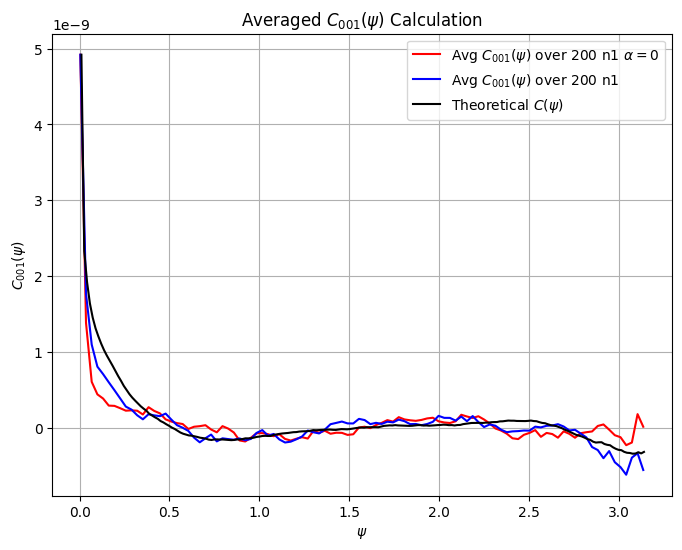

In [43]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)

n_anchors = 200

alpha = 2*np.pi/3
beta = 0
gamma = np.linspace(0, 2*np.pi, int(n_anchors))
c_planck1 = np.zeros_like(psi_values2)

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    if i%50 == 0:
        print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    c_planck1 += get_C001(rotated_planck_map, psi_values2, Delta_psi)

# Compute the average over the 10 iterations
c_planck_avg2 = c_planck1 / len(gamma)
norm2 = c_planck_avg2[0]/c_psi[0]

# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))
plt.plot(psi_values2, c_planck_avg/norm1, color="red", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =0$")
plt.plot(psi_values2, c_planck_avg2/norm2, color="blue", label=r"Avg $C_{001}(\psi)$ over 200 n1")
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)

#### change n_psi = 400

Rotated Sky Map 0: alpha=2.0943951023931953, beta=0, gamma=0.0
200, psi: 1.5747231346314754, C_001(psi):2.393383363438286e-09
200, psi: 1.5747231346314754, C_001(psi):3.035921039442046e-10
200, psi: 1.5747231346314754, C_001(psi):1.2923582193091273e-10
200, psi: 1.5747231346314754, C_001(psi):2.381297883539126e-10
200, psi: 1.5747231346314754, C_001(psi):5.913764765386195e-10
200, psi: 1.5747231346314754, C_001(psi):-4.61825847726009e-10
200, psi: 1.5747231346314754, C_001(psi):-1.1614457968966162e-10
200, psi: 1.5747231346314754, C_001(psi):4.660846602818398e-10
200, psi: 1.5747231346314754, C_001(psi):5.377655864624306e-10
200, psi: 1.5747231346314754, C_001(psi):7.376095991339649e-11
200, psi: 1.5747231346314754, C_001(psi):-4.711236638424174e-10
200, psi: 1.5747231346314754, C_001(psi):-1.5087251330696352e-09
200, psi: 1.5747231346314754, C_001(psi):-8.41697756055769e-10
200, psi: 1.5747231346314754, C_001(psi):-1.0013639319444759e-09
200, psi: 1.5747231346314754, C_001(psi):5.9485

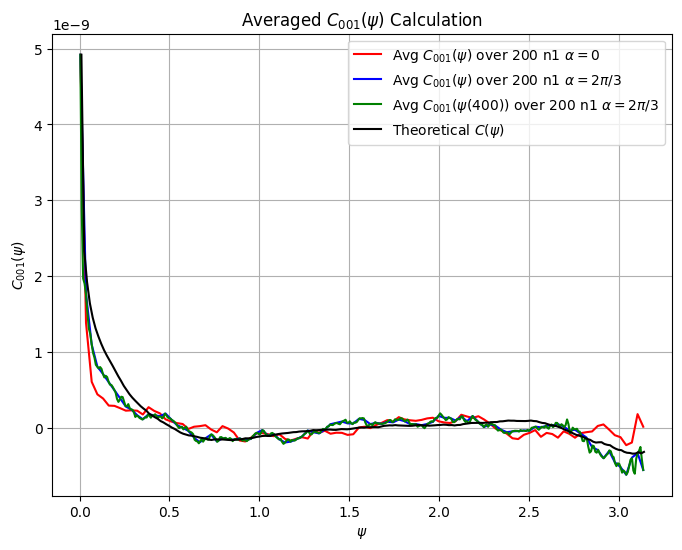

In [45]:
n_psi = 400
psi_values3 = np.linspace(0.004, np.pi-0.004, n_psi)

n_anchors = 200

alpha = 2*np.pi/3
beta = 0
gamma = np.linspace(0, 2*np.pi, int(n_anchors))
c_planck1 = np.zeros_like(psi_values3)

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    if i%50 == 0:
        print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    c_planck1 += get_C001(rotated_planck_map, psi_values3, Delta_psi)

# Compute the average over the 10 iterations
c_planck_avg3 = c_planck1 / len(gamma)
norm3 = c_planck_avg3[0]/c_psi[0]

# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))
plt.plot(psi_values2, c_planck_avg/norm1, color="red", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =0$")
plt.plot(psi_values2, c_planck_avg2/norm2, color="blue", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi_values3, c_planck_avg3/norm3, color="green", label=r"Avg $C_{001}(\psi (400))$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

#### change $\Delta \psi = 0.001$

Rotated Sky Map 0: alpha=2.0943951023931953, beta=0, gamma=0.0
Rotated Sky Map 50: alpha=2.0943951023931953, beta=0, gamma=1.578689775673263
Rotated Sky Map 100: alpha=2.0943951023931953, beta=0, gamma=3.157379551346526
Rotated Sky Map 150: alpha=2.0943951023931953, beta=0, gamma=4.736069327019789


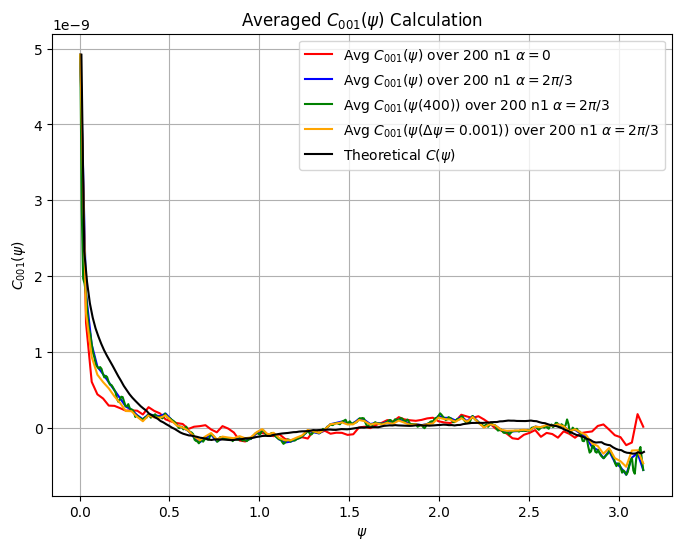

In [46]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)
Delta_psi = 0.001

n_anchors = 200

alpha = 2*np.pi/3
beta = 0
gamma = np.linspace(0, 2*np.pi, int(n_anchors))
c_planck1 = np.zeros_like(psi_values2)

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):
    if i%50 == 0:
        print(f"Rotated Sky Map {i}: alpha={alpha}, beta={beta}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha, beta, gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    c_planck1 += get_C001(rotated_planck_map, psi_values2, Delta_psi)

# Compute the average over the 10 iterations
c_planck_avg4 = c_planck1 / len(gamma)
norm4 = c_planck_avg4[0]/c_psi[0]

# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))
plt.plot(psi_values2, c_planck_avg/norm1, color="red", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =0$")
plt.plot(psi_values2, c_planck_avg2/norm2, color="blue", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi_values3, c_planck_avg3/norm3, color="green", label=r"Avg $C_{001}(\psi (400))$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi_values2, c_planck_avg4/norm4, color="orange", label=r"Avg $C_{001}(\psi (\Delta \psi=0.001))$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')
plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

## n1 are chosen randomly

In [47]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)

n_anchors = int(200)

alpha = np.random.uniform(0, 2*np.pi, n_anchors)
beta = np.random.uniform(0, 2*np.pi, n_anchors)
gamma = np.random.uniform(0, 2*np.pi, n_anchors)
c_planck2 = np.zeros_like(psi_values2)


# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):

    # t0 = time.perf_counter()
    if i%50 == 0:
        print(f"Rotated Sky Map {i}: alpha={alpha[i]}, beta={beta[i]}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha[i], beta[i], gam], deg =False)
    # t1 = time.perf_counter()    
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    # rotated_planck_map = fast_rotate_map(Planck_Smica_map, alpha[i], beta[i], gam)
    # t2 = time.perf_counter()
    # if abs(gam - np.pi/2) < 0.03:
    #     hp.mollview(
    #         rotated_planck_map,
    #         coord=["G"],
    #         title="Rotated Sky Map",
    #         unit="K",
    #         norm="hist",
    #         cmap = "coolwarm",
    #     )
    #     hp.graticule()
    #     hp.projscatter(0, 0, marker='*', color='red', s=100)
    #     plt.show()
    # t3 = time.perf_counter()

    c_planck2 += (get_C001(rotated_planck_map, psi_values2, Delta_psi))
    # t4 = time.perf_counter()


    # print(f"Timing for iteration {i}:")
    # print(f"  Rotator creation: {t1 - t0:.4f} s")
    # print(f"  Map rotation: {t2 - t0:.4f} s")
    # print(f"  Visualization (if executed): {t3 - t2:.4f} s")
    # print(f"  Correlation computation: {t4 - t3:.4f} s")
    # print("=" * 40)

# Compute the average over the n_anchors anchor points

c_planck2 /= n_anchors

Rotated Sky Map 0: alpha=0.9069322596014697, beta=2.311546683044632, gamma=2.7668275041029586
Rotated Sky Map 50: alpha=4.297215152085782, beta=0.5618088373899114, gamma=0.45143763746525284
Rotated Sky Map 100: alpha=1.1451552375088678, beta=2.0265165418421875, gamma=5.330333754261885
Rotated Sky Map 150: alpha=4.699119425004257, beta=2.3408627565704583, gamma=0.470017481956799


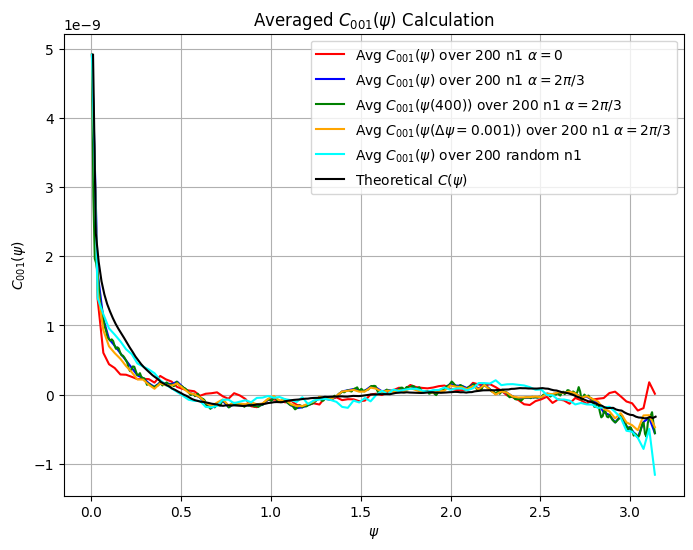

In [48]:
norm = c_planck2[0]/c_psi[0]


# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))

# plt.plot(psi_values2, c_planck2, color="orange", label=r"Avg $C_{001}(\psi)$ over 100 random n1")
plt.plot(psi_values2, c_planck_avg/norm1, color="red", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =0$")
plt.plot(psi_values2, c_planck_avg2/norm2, color="blue", label=r"Avg $C_{001}(\psi)$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi_values3, c_planck_avg3/norm3, color="green", label=r"Avg $C_{001}(\psi (400))$ over 200 n1 $\alpha =2\pi/3$")
plt.plot(psi_values2, c_planck_avg4/norm4, color="orange", label=r"Avg $C_{001}(\psi (\Delta \psi=0.001))$ over 200 n1 $\alpha =2\pi/3$")

plt.plot(psi_values2, c_planck2/norm,color ="cyan", label=r"Avg $C_{001}(\psi)$ over 200 random n1")

plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')

plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
n_psi = 100
psi_values2 = np.linspace(0.004, np.pi-0.004, n_psi)

n_anchors = int(1000)

alpha = np.random.uniform(0, 2*np.pi, n_anchors)
beta = np.random.uniform(0, 2*np.pi, n_anchors)
gamma = np.random.uniform(0, 2*np.pi, n_anchors)
c_planck3 = np.zeros_like(psi_values2)

# Rotate the sky map using Healpy's rotator
for i, gam in enumerate(gamma):

    print(f"Rotated Sky Map {i}: alpha={alpha[i]}, beta={beta[i]}, gamma={gam}")
    rotation= hp.rotator.Rotator( rot = [alpha[i], beta[i], gam], deg =False)
    rotated_planck_map = rotation.rotate_map_pixel(Planck_Smica_map)

    c_planck3 += (get_C001(rotated_planck_map, psi_values2, Delta_psi))

# Compute the average over the n_anchors anchor points

c_planck3 /= n_anchors

Rotated Sky Map 0: alpha=5.720374535462552, beta=2.8327039339900204, gamma=2.8574670723129545
Rotated Sky Map 1: alpha=5.918830859658042, beta=5.456986934967704, gamma=1.3435478078178353
Rotated Sky Map 2: alpha=5.8413841546724266, beta=1.7215238153044898, gamma=3.5867961882916624
Rotated Sky Map 3: alpha=3.756106584244636, beta=0.55365354463826, gamma=5.06941527903665
Rotated Sky Map 4: alpha=3.2634641507446136, beta=5.029670817358684, gamma=0.2665607425910658
Rotated Sky Map 5: alpha=1.6900011919208262, beta=5.4560561841656945, gamma=2.5969034377452944
Rotated Sky Map 6: alpha=1.018318058873117, beta=5.281087230396163, gamma=4.59095143559579
Rotated Sky Map 7: alpha=3.500328045758092, beta=2.0690505202747347, gamma=2.1504472067988587
Rotated Sky Map 8: alpha=0.9330324312552103, beta=0.19393236179246745, gamma=0.2620468569009534
Rotated Sky Map 9: alpha=1.0814346084453517, beta=0.877230246588279, gamma=3.7157520987976724
Rotated Sky Map 10: alpha=2.2414823577983314, beta=5.77656498373

<Figure size 800x600 with 0 Axes>

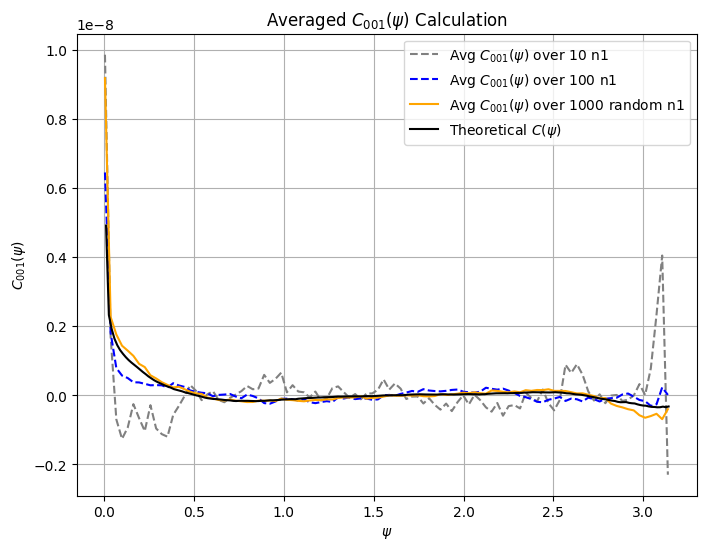

In [61]:
# norm = np.sum(np.abs(c_psi))/np.sum(np.abs(c_planck3))
# norm2 = c_planck2[0]/c_psi[0]

# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))
# ---- Plot the averaged C(psi) ----
plt.figure(figsize=(8, 6))

plt.plot(psi_values2, c_planck_avg1,"--", color="grey", label=r"Avg $C_{001}(\psi)$ over 10 n1")
plt.plot(psi_values2, c_planck_avg,"--", color="blue", label=r"Avg $C_{001}(\psi)$ over 100 n1")
plt.plot(psi_values2, c_planck3, color="orange", label=r"Avg $C_{001}(\psi)$ over 1000 random n1")
# plt.plot(psi_values2, c_planck_avg, color="blue", label=r"Avg $C_{001}(\psi)$ over 100 n1")

plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$')

plt.xlabel(r"$\psi$")
plt.ylabel(r"$C_{001}(\psi)$")
plt.title(r"Averaged $C_{001}(\psi)$ Calculation")
plt.legend()
plt.grid(True)
plt.show()